# S&P 500 Change Point Detection (PELT + Monte Carlo penalty selection)

1. Pull S&P 500 data with `yfinance`
2. Detect change points with `ruptures`' PELT algorithm
3. Use a Monte Carlo permutation test to get a statistically-justified lower bound on the PELT penalty (much faster than sweeping a full CROPS penalty range, which got too slow to be practical here)
4. Plot all resulting change points

In [54]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

%matplotlib inline

## Download S&P 500 data

In [55]:
sp500 = yf.download("^GSPC", period="10y", interval="1d", auto_adjust=True)
sp500 = sp500[["Close"]].dropna()
sp500.columns = ["Close"]
sp500.head()

[*********************100%***********************]  1 of 1 completed


,Close
Date,
2016-08-08,2180.889893
2016-08-09,2181.739990
2016-08-10,2175.489990
2016-08-11,2185.790039
2016-08-12,2184.050049


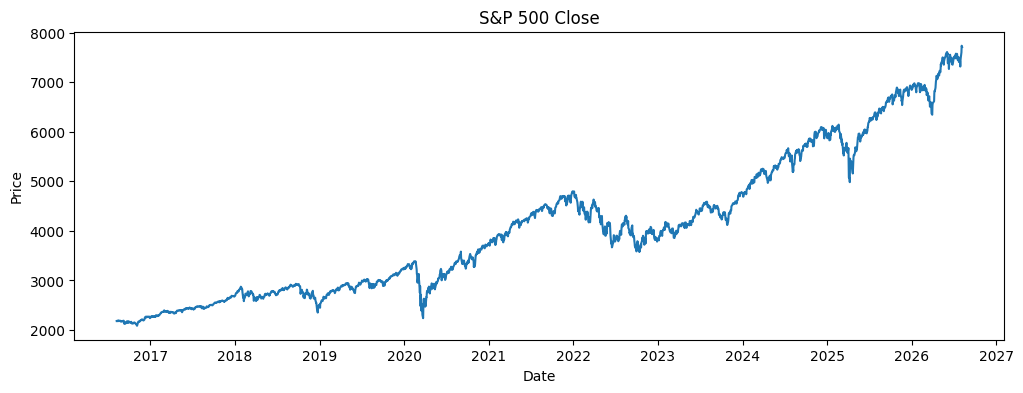

In [56]:
signal = sp500["Close"].to_numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sp500.index, signal)
ax.set_title("S&P 500 Close")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.show()

## PELT change point detection

PELT (Pruned Exact Linear Time) finds the exact optimal segmentation for a *single* penalty value in roughly linear time.

Default penalty: 16246386.03 -> 7 change points


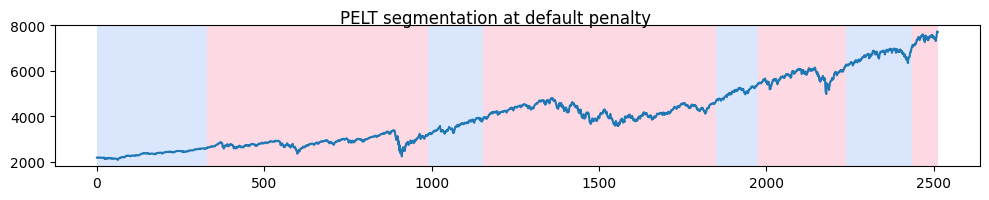

In [57]:
model = "l2"  # segment cost model: mean-shift, sum of squared errors
algo = rpt.Pelt(model=model, min_size=10, jump=1).fit(signal)

default_pen = np.log(len(signal)) * np.var(signal)  # BIC-style default penalty
bkps_default = algo.predict(pen=default_pen)
print(f"Default penalty: {default_pen:.2f} -> {len(bkps_default) - 1} change points")

rpt.display(signal, bkps_default)
plt.suptitle("PELT segmentation at default penalty")
plt.show()

## Statistically-justified penalty via Monte Carlo simulation

CROPS finds the exact penalty threshold by re-running full PELT over and over. On this machine, individual `Pelt.predict()` calls were taking a long time (system under heavy load from another process), so sweeping ~10-20 of them was too slow.

Instead, this uses a **Monte Carlo permutation test** to get a data-driven lower bound on the penalty, with no repeated PELT calls at all:
1. Shuffle the series many times — this destroys any real change points while keeping each column's own distribution intact.
2. For each shuffle, compute the largest possible cost reduction from a single split (closed-form, O(n), no PELT needed).
3. Take the (1 − alpha) quantile of that "pure noise" distribution — this is the minimum penalty needed so PELT doesn't start flagging noise as a change point.

Then a single `Pelt.predict()` call at that penalty gives the final segmentation.

In [58]:
def mc_penalty_lower_bound(signal, n_sims=200, alpha=0.05, min_size=10, seed=0):
    """Permutation-test lower bound for the PELT penalty.

    Shuffles the signal in time (destroying any real change points while
    preserving each column's marginal distribution) and, for each shuffle,
    computes the largest possible cost reduction from a single split using
    the same sum-of-squares cost as rpt.Pelt(model="l2"). The (1 - alpha)
    quantile of that null distribution is the minimum penalty needed so PELT
    doesn't start flagging pure noise as change points. Runs in closed form
    (no PELT calls), so it's fast regardless of how slow a full PELT run is.
    """
    x = np.asarray(signal, dtype=float)
    if x.ndim == 1:
        x = x[:, None]
    n, d = x.shape
    ts = np.arange(min_size, n - min_size)
    rng = np.random.default_rng(seed)

    total_cost = x.var(axis=0).sum() * n
    null_gains = np.empty(n_sims)
    for i in range(n_sims):
        perm = rng.permutation(x, axis=0)
        cx = np.concatenate([np.zeros((1, d)), np.cumsum(perm, axis=0)])
        cx2 = np.concatenate([np.zeros((1, d)), np.cumsum(perm**2, axis=0)])

        def seg_cost(a, b):
            length = (b - a).astype(float)
            s = cx[b] - cx[a]
            s2 = cx2[b] - cx2[a]
            return (s2 - s**2 / length[:, None]).sum(axis=-1)

        cost_left = seg_cost(0, ts)
        cost_right = seg_cost(ts, n)
        null_gains[i] = (total_cost - (cost_left + cost_right)).max()

    penalty = float(np.quantile(null_gains, 1 - alpha))
    return penalty, null_gains


mc_pen, null_gains = mc_penalty_lower_bound(signal, n_sims=200, alpha=0.05, min_size=10, seed=0)
print(f"MC lower-bound penalty (alpha=0.05): {mc_pen:.2f}")

algo = rpt.Pelt(model=model, min_size=10, jump=5).fit(signal)
bkps_mc = algo.predict(pen=mc_pen)
print(f"-> {len(bkps_mc) - 1} change points at the MC-selected penalty")

MC lower-bound penalty (alpha=0.05): 23961980.49
-> 7 change points at the MC-selected penalty


## Plot the change points found using the MC-selected penalty

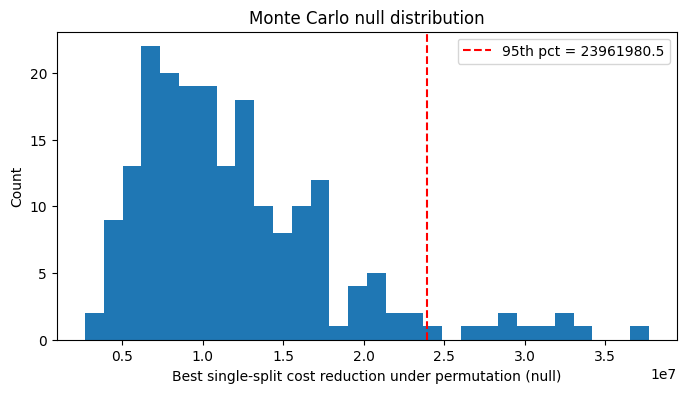

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_gains, bins=30)
ax.axvline(mc_pen, color="red", linestyle="--", label=f"95th pct = {mc_pen:.1f}")
ax.set_xlabel("Best single-split cost reduction under permutation (null)")
ax.set_ylabel("Count")
ax.set_title("Monte Carlo null distribution")
ax.legend()
plt.show()

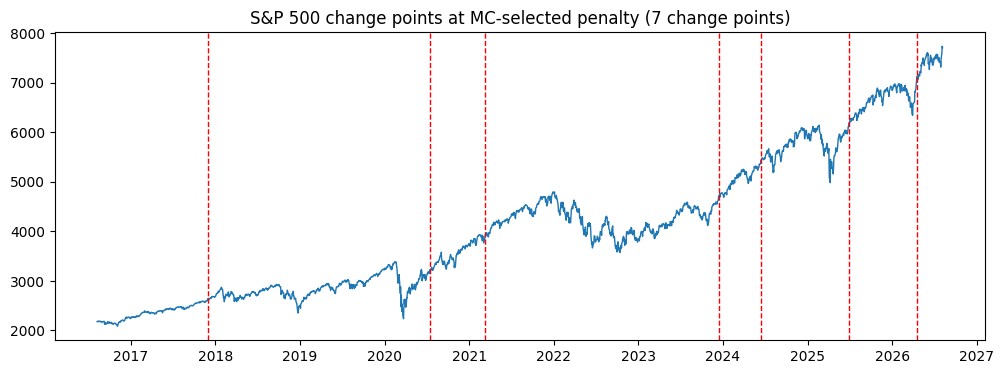

In [60]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sp500.index, signal, lw=1)
for cp in bkps_mc[:-1]:
    ax.axvline(sp500.index[cp], color="red", linestyle="--", lw=1)
ax.set_title(f"S&P 500 change points at MC-selected penalty ({len(bkps_mc) - 1} change points)")
plt.show()

## Sharpe ratio of a regime-shift trading strategy

Strategy: stay fully invested in the S&P 500 the whole time, but treat each detected change point
`bkps_mc` as a trade boundary — exit the old regime and re-enter at that same price. The Sharpe
ratio here is computed on the sequence of **per-regime returns** (not daily returns), annualized
by the average number of regimes per year. Risk-free rate assumed 0% and transaction costs ignored.

In [61]:
trade_bounds = [0] + list(bkps_mc)
trade_returns = np.array([
    signal[end - 1] / signal[start] - 1
    for start, end in zip(trade_bounds[:-1], trade_bounds[1:])
])

for (start, end), r in zip(zip(trade_bounds[:-1], trade_bounds[1:]), trade_returns):
    print(f"{sp500.index[start].date()} -> {sp500.index[end - 1].date()}: {r:+.2%}")

mean_r, std_r = trade_returns.mean(), trade_returns.std(ddof=1)
sharpe_per_trade = mean_r / std_r

total_years = (sp500.index[-1] - sp500.index[0]).days / 365.25
trades_per_year = len(trade_returns) / total_years
sharpe_annualized = sharpe_per_trade * np.sqrt(trades_per_year)

print(f"\nPer-regime Sharpe ratio: {sharpe_per_trade:.2f}")
print(f"Annualized Sharpe ratio: {sharpe_annualized:.2f}  ({len(trade_returns)} trades over {total_years:.1f} years, rf=0)")

2016-08-08 -> 2017-11-27: +19.28%
2017-11-28 -> 2020-07-14: +21.72%
2020-07-15 -> 2021-03-10: +20.83%
2021-03-11 -> 2023-12-12: +17.88%
2023-12-13 -> 2024-06-12: +15.17%
2024-06-13 -> 2025-06-27: +13.61%
2025-06-30 -> 2026-04-15: +13.18%
2026-04-16 -> 2026-08-06: +9.50%

Per-regime Sharpe ratio: 3.87
Annualized Sharpe ratio: 3.46  (8 trades over 10.0 years, rf=0)


## Classify each regime as bullish or bearish, then backtest

Heuristic: for each detected change point, look at the **3 most recent local peaks** (swing highs)
in the price series *before* that change point. If those peaks are trending upward (the most
recent of the three is higher than the oldest) label the regime that starts at the change point
**bullish**; if trending downward, label it **bearish**.

Backtest: go long during bullish-labeled regimes, short during bearish-labeled regimes, flat
before the first change point (no signal yet). Trades execute the day *after* the signal to avoid
look-ahead bias. Caveat: this is an in-sample backtest — the change points and peaks are detected
using the same data being traded — so treat it as illustrative, not a forward-looking guarantee.
No transaction costs or slippage are modeled.

Packaged as reusable functions below so the same logic can be reapplied to a different signal,
change-point set, or peak-detection setting without copy-pasting.

In [62]:
from scipy.signal import find_peaks


def classify_regimes(cp_list, peak_idx, peak_vals, n_peaks=3):
    """Label the regime starting at each change point bullish/bearish/neutral,
    based on the trend of the n_peaks most recent swing highs before it."""
    def classify_one(cp_index):
        prior = [(i, v) for i, v in zip(peak_idx, peak_vals) if i < cp_index]
        if len(prior) < n_peaks:
            return "neutral"
        vals = [v for _, v in prior[-n_peaks:]]
        if vals[-1] > vals[0]:
            return "bullish"
        elif vals[-1] < vals[0]:
            return "bearish"
        return "neutral"
    return [classify_one(cp) for cp in cp_list]


def backtest_regime_strategy(prices, bkps, labels):
    """Long during bullish regimes, short during bearish, flat before the first
    change point. Trades execute the day after the signal (no look-ahead)."""
    daily_ret = prices.pct_change().fillna(0)
    position = pd.Series(0.0, index=prices.index)
    for start, end, label in zip(bkps[:-1], bkps[1:], labels):
        position.iloc[start:end] = 1.0 if label == "bullish" else (-1.0 if label == "bearish" else 0.0)
    strategy_ret = position.shift(1).fillna(0) * daily_ret
    return strategy_ret, daily_ret


def annualized_sharpe(returns, periods=252, rf=0.0):
    excess = returns - rf / periods
    return excess.mean() / excess.std() * np.sqrt(periods)


def max_drawdown(cum):
    return ((cum - cum.cummax()) / cum.cummax()).min()


def backtest_summary(strategy_ret, daily_ret):
    cum_strategy = (1 + strategy_ret).cumprod()
    cum_bh = (1 + daily_ret).cumprod()
    summary = {
        "strategy_total_return": cum_strategy.iloc[-1] - 1,
        "bh_total_return": cum_bh.iloc[-1] - 1,
        "strategy_sharpe": annualized_sharpe(strategy_ret),
        "bh_sharpe": annualized_sharpe(daily_ret),
        "strategy_max_drawdown": max_drawdown(cum_strategy),
        "bh_max_drawdown": max_drawdown(cum_bh),
    }
    return summary, cum_strategy, cum_bh


def plot_regime_backtest(dates, prices, peak_idx, cp_list, labels, cum_strategy, cum_bh, title="S&P 500"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(dates, prices, lw=1, color="black")
    axes[0].plot(dates[peak_idx], prices[peak_idx], "v", color="gray", ms=4, label="detected peaks")
    for cp, label in zip(cp_list, labels):
        color = "green" if label == "bullish" else ("red" if label == "bearish" else "gray")
        axes[0].axvline(dates[cp], color=color, linestyle="--", lw=1)
    axes[0].set_title(f"{title} with bullish (green) / bearish (red) regime shifts")
    axes[0].legend()

    axes[1].plot(cum_strategy.index, cum_strategy, label="Regime strategy")
    axes[1].plot(cum_bh.index, cum_bh, label="Buy & hold")
    axes[1].set_title("Cumulative return: strategy vs. buy & hold")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [63]:
# relative prominence, not signal.std(): price *level* std blows up over a trending 10y series
peak_idx, _ = find_peaks(signal, distance=10, prominence=np.median(signal) * 0.03)
peak_vals = signal[peak_idx]
print(f"{len(peak_idx)} local peaks detected")

cp_list = list(bkps_mc[:-1])
labels = classify_regimes(cp_list, peak_idx, peak_vals, n_peaks=3)
for cp, label in zip(cp_list, labels):
    print(f"{sp500.index[cp].date()}: {label}")

strategy_ret, daily_ret = backtest_regime_strategy(sp500["Close"], bkps_mc, labels)
summary, cum_strategy, cum_bh = backtest_summary(strategy_ret, daily_ret)

print(f"\nStrategy total return:   {summary['strategy_total_return']:+.1%}")
print(f"Buy & hold total return: {summary['bh_total_return']:+.1%}")
print(f"Strategy Sharpe:   {summary['strategy_sharpe']:.2f}")
print(f"Buy & hold Sharpe: {summary['bh_sharpe']:.2f}")
print(f"Strategy max drawdown:   {summary['strategy_max_drawdown']:.1%}")
print(f"Buy & hold max drawdown: {summary['bh_max_drawdown']:.1%}")

plot_regime_backtest(sp500.index, signal, peak_idx, cp_list, labels, cum_strategy, cum_bh)

SyntaxError: invalid syntax (2675794604.py, line 2)

## Multivariate change point detection: S&P 500, 5-year Treasury yield, and sentiment

To find change points jointly across multiple series, `ruptures`' cost functions accept a
multi-dimensional signal directly (shape `(n_samples, n_features)`) — the same `Pelt`/`crops`
machinery from above works unchanged, it just detects shifts in the *joint* distribution across
all columns at once instead of a single series.

Series used:
- **S&P 500** daily log returns (equity market)
- **5-year Treasury yield** (`^FVX`, CBOE 5 Year T-Note yield) daily change — a standard free proxy for "5-year government bond" moves (bond prices move inversely to yield, so a yield change point *is* a bond price change point)
- **Market sentiment**: there's no free, unauthenticated API for genuine NLP-derived media/news sentiment (that requires a paid provider or a news API key). As a widely used stand-in, this uses **`^VIX`** (CBOE Volatility Index) — the market's own real-time "fear gauge" derived from option prices, commonly used as a sentiment proxy in finance. Swap in a real news-sentiment series here if you have access to one (e.g. RavenPack, Bloomberg, or a labeled headline dataset).

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


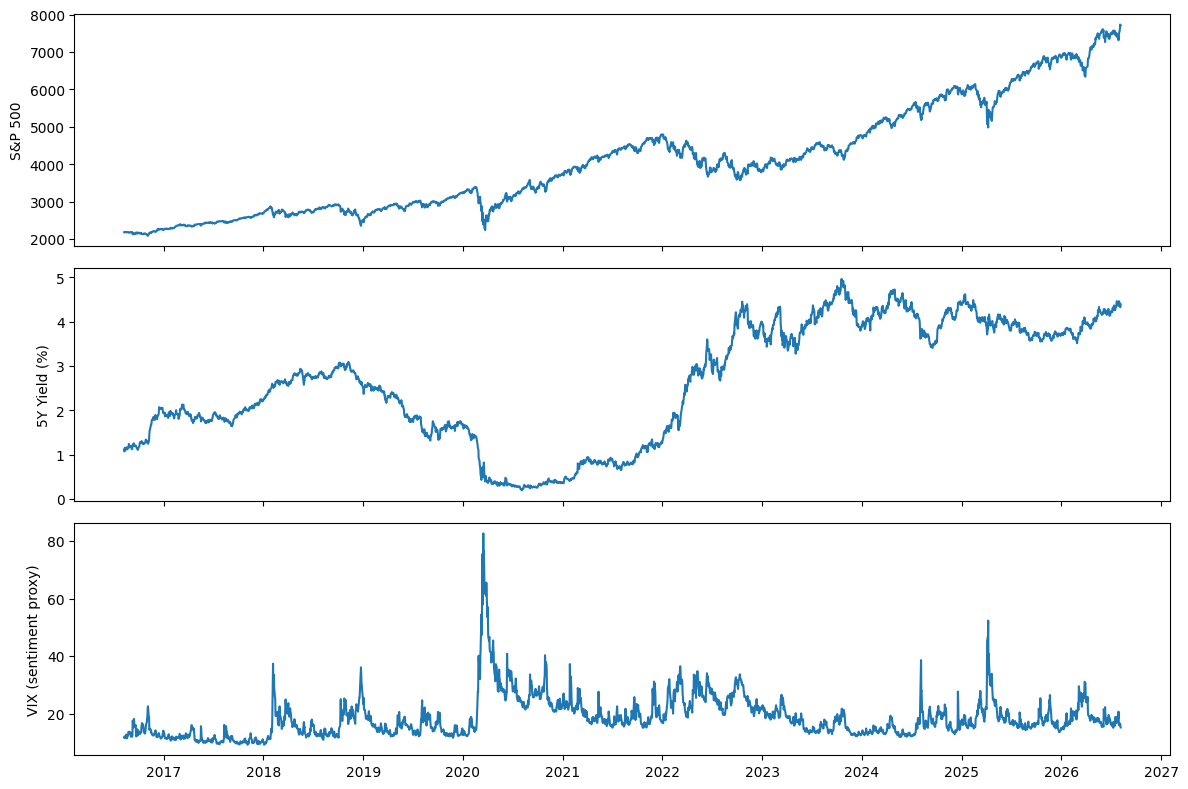

(2511, 3)

In [ ]:
bond = yf.download("^FVX", period="10y", interval="1d", auto_adjust=True)[["Close"]].dropna()
bond.columns = ["Yield5Y"]  # yfinance can return MultiIndex columns; rename() no-ops on those, so reassign directly
vix = yf.download("^VIX", period="10y", interval="1d", auto_adjust=True)[["Close"]].dropna()
vix.columns = ["VIX"]

mv = sp500.rename(columns={"Close": "SP500"}).join(bond, how="inner").join(vix, how="inner").dropna()

mv["SP500_ret"] = np.log(mv["SP500"]).diff()
mv["Yield5Y_chg"] = mv["Yield5Y"].diff()
mv = mv.dropna()

# z-score each transformed series so no single series dominates the joint cost
mv_z = mv[["SP500_ret", "Yield5Y_chg", "VIX"]].apply(lambda c: (c - c.mean()) / c.std())
mv_signal = mv_z.to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(mv.index, mv["SP500"]); axes[0].set_ylabel("S&P 500")
axes[1].plot(mv.index, mv["Yield5Y"]); axes[1].set_ylabel("5Y Yield (%)")
axes[2].plot(mv.index, mv["VIX"]); axes[2].set_ylabel("VIX (sentiment proxy)")
plt.tight_layout()
plt.show()

mv_signal.shape

### Joint PELT with an MC-selected penalty

Same `mc_penalty_lower_bound()` from above — it works unchanged on the 3-column signal since the
null-distribution calculation is already vectorized across dimensions.

In [ ]:
mv_model = "l2"
mv_mc_pen, mv_null_gains = mc_penalty_lower_bound(mv_signal, n_sims=200, alpha=0.05, min_size=10, seed=0)
print(f"MC lower-bound penalty (alpha=0.05): {mv_mc_pen:.2f}")

mv_algo = rpt.Pelt(model=mv_model, min_size=10, jump=5).fit(mv_signal)
mv_bkps_mc = mv_algo.predict(pen=mv_mc_pen)
print(f"-> {len(mv_bkps_mc) - 1} joint change points at the MC-selected penalty")

MC lower-bound penalty (alpha=0.05): 17.52
-> 17 joint change points at the MC-selected penalty


### Plot the joint change points across all three series

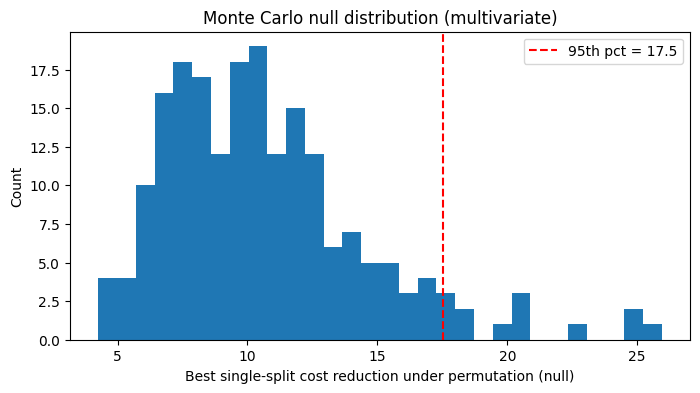

Joint segmentation: 17 change points (penalty=17.52)
  2018-01-30
  2018-04-26
  2018-10-09
  2019-01-29
  2020-02-25
  2020-03-10
  2020-03-24
  2020-04-07
  2020-04-29
  2020-07-17
  2021-03-15
  2022-01-19
  2022-11-10
  2023-04-06
  2025-02-21
  2025-04-04
  2025-04-28


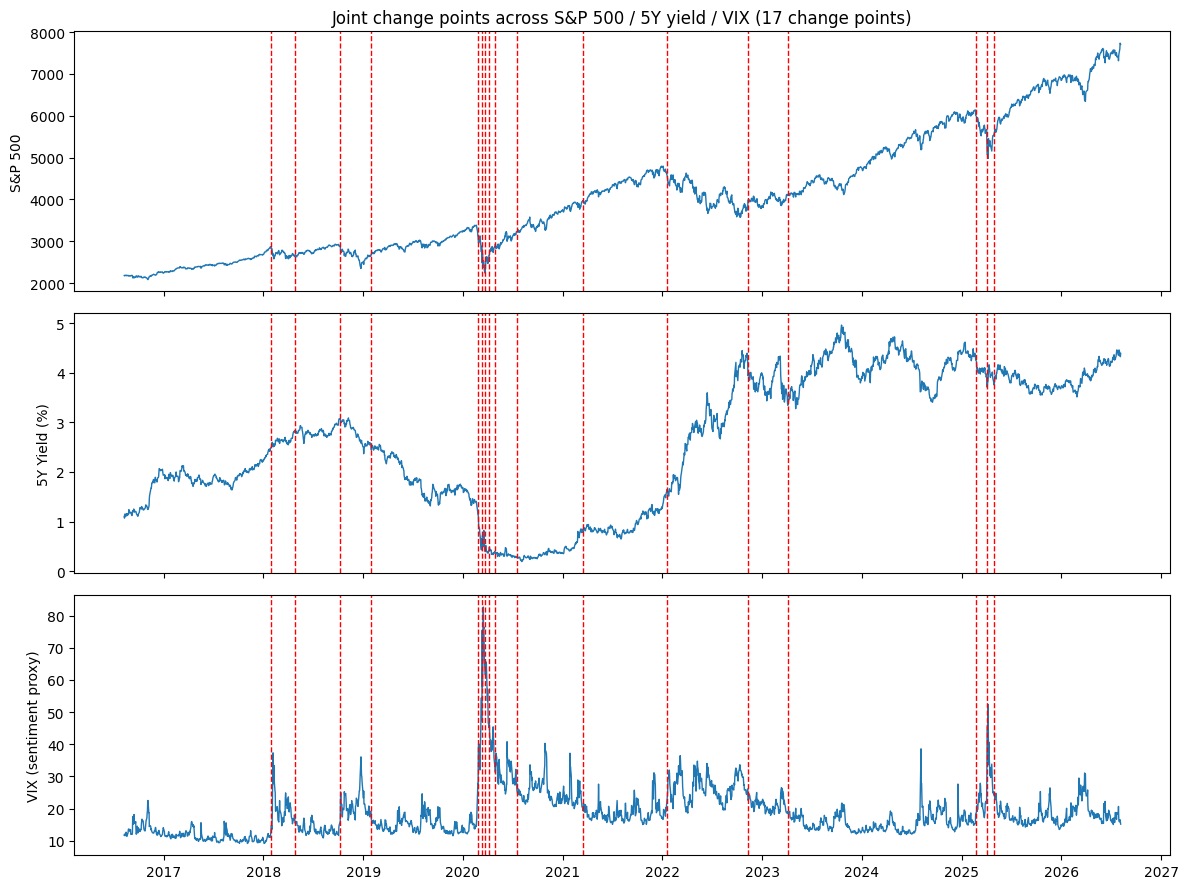

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mv_null_gains, bins=30)
ax.axvline(mv_mc_pen, color="red", linestyle="--", label=f"95th pct = {mv_mc_pen:.1f}")
ax.set_xlabel("Best single-split cost reduction under permutation (null)")
ax.set_ylabel("Count")
ax.set_title("Monte Carlo null distribution (multivariate)")
ax.legend()
plt.show()

cp_dates = [mv.index[cp] for cp in mv_bkps_mc[:-1]]
print(f"Joint segmentation: {len(mv_bkps_mc) - 1} change points (penalty={mv_mc_pen:,.2f})")
for d in cp_dates:
    print(" ", d.date())

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
series_map = [("SP500", "S&P 500"), ("Yield5Y", "5Y Yield (%)"), ("VIX", "VIX (sentiment proxy)")]
for ax, (col, label) in zip(axes, series_map):
    ax.plot(mv.index, mv[col], lw=1)
    for d in cp_dates:
        ax.axvline(d, color="red", linestyle="--", lw=1)
    ax.set_ylabel(label)
axes[0].set_title(f"Joint change points across S&P 500 / 5Y yield / VIX ({len(mv_bkps_mc) - 1} change points)")
plt.tight_layout()
plt.show()

## Compare: univariate vs. joint (multivariate) change-point strategy

Apply the same `classify_regimes` / `backtest_regime_strategy` functions to the change points
detected jointly across S&P 500 / 5Y Treasury yield / VIX (`mv_bkps_mc`), still trading the S&P
500 itself — then compare against the S&P-500-only strategy from earlier.

Note: `mv` starts later and has fewer rows than `sp500` (inner joins with the 5Y yield / VIX data,
plus dropping the first row to compute `.diff()`), so the two backtests don't run over an
identical date range — treat this as a directional comparison of the two change-point detection
approaches, not a strictly apples-to-apples one.

In [ ]:
mv_prices = mv["SP500"]
mv_price_arr = mv_prices.to_numpy()

mv_peak_idx, _ = find_peaks(mv_price_arr, distance=10, prominence=np.median(mv_price_arr) * 0.03)
mv_peak_vals = mv_price_arr[mv_peak_idx]

mv_cp_list = list(mv_bkps_mc[:-1])
mv_labels = classify_regimes(mv_cp_list, mv_peak_idx, mv_peak_vals, n_peaks=3)
for cp, label in zip(mv_cp_list, mv_labels):
    print(f"{mv.index[cp].date()}: {label}")

mv_strategy_ret, mv_daily_ret = backtest_regime_strategy(mv_prices, mv_bkps_mc, mv_labels)
mv_summary, mv_cum_strategy, mv_cum_bh = backtest_summary(mv_strategy_ret, mv_daily_ret)

print(f"\nUnivariate sample:   {sp500.index[0].date()} to {sp500.index[-1].date()} ({len(sp500)} days)")
print(f"Multivariate sample: {mv.index[0].date()} to {mv.index[-1].date()} ({len(mv)} days)")

2018-01-30: neutral
2018-04-26: neutral
2018-10-09: neutral
2019-01-29: neutral
2020-02-25: neutral
2020-03-10: neutral
2020-03-24: neutral
2020-04-07: neutral
2020-04-29: neutral
2020-07-17: neutral
2021-03-15: neutral
2022-01-19: neutral
2022-11-10: neutral
2023-04-06: neutral
2025-02-21: bullish
2025-04-04: bullish
2025-04-28: bullish

Univariate sample:   2016-08-08 to 2026-08-06 (2513 days)
Multivariate sample: 2016-08-09 to 2026-08-06 (2511 days)


In [ ]:
comparison = pd.DataFrame({
    "Univariate (S&P 500 only)": summary,
    "Multivariate (S&P 500 + 5Y yield + VIX)": mv_summary,
}).T
comparison

,strategy_total_return,bh_total_return,strategy_sharpe,bh_sharpe,strategy_max_drawdown,bh_max_drawdown
Univariate (S&P 500 only),0.242550,2.535236,0.540627,0.791199,-0.090975,-0.33925
Multivariate (S&P 500 + 5Y yield + VIX),0.282187,2.533858,0.407743,0.791298,-0.171352,-0.33925


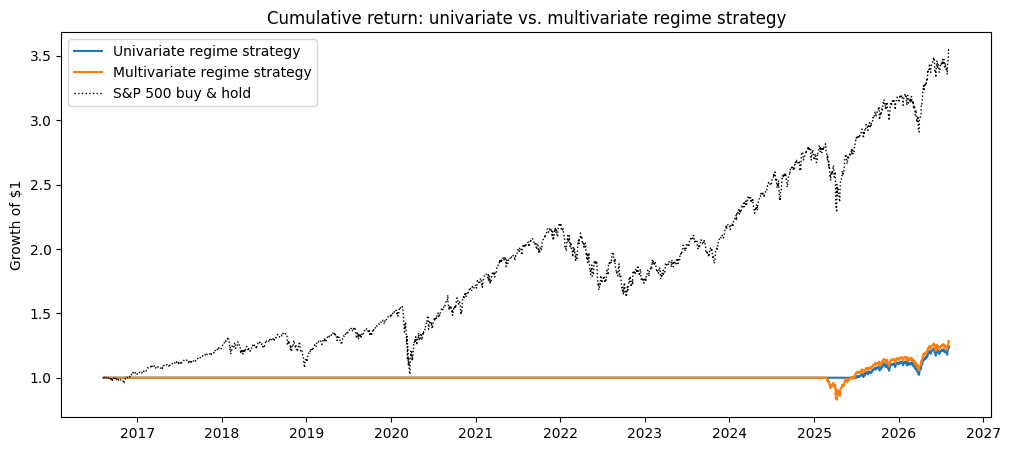

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_strategy.index, cum_strategy, label="Univariate regime strategy")
ax.plot(mv_cum_strategy.index, mv_cum_strategy, label="Multivariate regime strategy")
ax.plot(cum_bh.index, cum_bh, label="S&P 500 buy & hold", color="black", lw=1, linestyle=":")
ax.set_title("Cumulative return: univariate vs. multivariate regime strategy")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.show()

## Beyond the ad hoc heuristic: literature-based regime classification

The "last 3 peaks" rule used above is a hand-rolled heuristic. Two well-established methods from
the literature do this more rigorously:

- **Hamilton (1989)**, *A New Approach to the Economic Analysis of Nonstationary Time Series and
  the Business Cycle*, Econometrica — the classic two-state **Markov-switching model**: fit a
  Gaussian Hidden Markov Model to daily returns, let it find a low-mean/high-vol state and a
  high-mean/low-vol state, and decode the most likely state path.
- **Pagan & Sossounov (2003)**, *A simple framework for analysing bull and bear markets*, Journal
  of Applied Econometrics — extends the Bry & Boschan (1971) NBER turning-point algorithm: find
  alternating local peaks/troughs, then discard any phase shorter than a minimum length or smaller
  than a minimum amplitude (literature defaults: ~20 trading days, ~20% move).

Both are implemented below and backtested the same way as before, using a proper **train/test
split** this time (first 70% of history to build/tune, last 30% held out) so "beats buy & hold"
means something.

### Pagan & Sossounov (2003) bull/bear phases

Turning points come from `scipy.signal.find_peaks` on the raw price (and its negation, for
troughs), then two filters are applied iteratively: merge/drop any turning point that creates a
phase shorter than `min_phase_days` or smaller than `min_amplitude`. This is a practical
implementation of the paper's idea, not a byte-for-byte port of their original algorithm.

In [ ]:
def enforce_alternation(pts, prices):
    """Collapse consecutive same-type turning points, keeping the more extreme one."""
    out = []
    for idx, kind in pts:
        if out and out[-1][1] == kind:
            prev_idx, prev_kind = out[-1]
            if kind == "peak" and prices[idx] > prices[prev_idx]:
                out[-1] = (idx, kind)
            elif kind == "trough" and prices[idx] < prices[prev_idx]:
                out[-1] = (idx, kind)
        else:
            out.append((idx, kind))
    return out


def bry_boschan_turning_points(prices, window=20):
    peak_idx, _ = find_peaks(prices, distance=window)
    trough_idx, _ = find_peaks(-prices, distance=window)
    points = sorted([(int(i), "peak") for i in peak_idx] + [(int(i), "trough") for i in trough_idx])
    return enforce_alternation(points, prices)


def pagan_sossounov_phases(prices, window=20, min_phase_days=20, min_amplitude=0.20):
    """Returns a list of (start_idx, end_idx, "bullish"/"bearish") phases."""
    points = bry_boschan_turning_points(prices, window=window)
    changed, guard = True, 0
    while changed and guard < 2000:
        guard += 1
        changed = False
        points = enforce_alternation(points, prices)
        for i in range(len(points) - 1):
            idx0, kind0 = points[i]
            idx1, kind1 = points[i + 1]
            phase_len = idx1 - idx0
            amplitude = abs(prices[idx1] / prices[idx0] - 1)
            if phase_len < min_phase_days or amplitude < min_amplitude:
                del points[i + 1]
                changed = True
                break
    points = enforce_alternation(points, prices)
    phases = [
        (idx0, idx1, "bullish" if kind0 == "trough" else "bearish")
        for (idx0, kind0), (idx1, kind1) in zip(points[:-1], points[1:])
    ]
    return phases, points


phases_ps, points_ps = pagan_sossounov_phases(signal, window=20, min_phase_days=20, min_amplitude=0.20)
print(f"{len(points_ps)} turning points -> {len(phases_ps)} phases")
for idx0, idx1, label in phases_ps:
    print(f"  {sp500.index[idx0].date()} -> {sp500.index[idx1].date()}: {label} ({signal[idx1]/signal[idx0]-1:+.1%})")

### Hamilton (1989) Markov-switching model

A 2-state Gaussian HMM fit on **daily returns from the training period only** (`train_mask`
defined below), then used to decode the most-likely state for the *entire* series. This keeps the
model itself out-of-sample-honest: nothing about the test period informs the fitted state means or
transition matrix.

In [ ]:
from hmmlearn.hmm import GaussianHMM

split = int(len(sp500) * 0.7)
train_mask = pd.Series(False, index=sp500.index)
train_mask.iloc[:split] = True
test_mask = ~train_mask
print(f"Train: {sp500.index[0].date()} -> {sp500.index[split-1].date()} ({split} days)")
print(f"Test:  {sp500.index[split].date()} -> {sp500.index[-1].date()} ({len(sp500)-split} days)")

returns_full = sp500["Close"].pct_change().fillna(0)
X_train_ret = returns_full.iloc[1:split].to_numpy().reshape(-1, 1)

hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=0)
hmm.fit(X_train_ret)  # fit on TRAIN ONLY

X_full_ret = returns_full.iloc[1:].to_numpy().reshape(-1, 1)
states_full = hmm.predict(X_full_ret)
bull_state = int(np.argmax(hmm.means_.flatten()))

print(f"\nState means (daily return): {hmm.means_.flatten()}")
print(f"Bullish state = {bull_state}, fraction of days classified bullish: {(states_full == bull_state).mean():.1%}")

pos_hmm = pd.Series(0.0, index=sp500.index)
pos_hmm.iloc[1:] = np.where(states_full == bull_state, 1.0, -1.0)

## Paper implementation: multiple change point detection for high-dimensional data

[Multiple change point detection for high-dimensional data](https://www.researchgate.net/publication/379274233_Multiple_change_point_detection_for_high-dimensional_data)
(*TEST*, 2024, DOI [10.1007/s11749-024-00926-w](https://doi.org/10.1007/s11749-024-00926-w))
proposes a method (the authors call it **PULSE**) for multiple change point detection in
high-dimensional data that doesn't require assuming a sparse or dense signal structure. Per the
abstract and summaries available (the full text is paywalled, so this isn't a line-by-line port of
their estimator): the core idea is a sequence of **signal-screening-based local U-statistics** —
scan across time with a local two-window statistic per dimension, *screen out* dimensions that
show no evidence of a shift at that point (so a handful of noisy dimensions don't dilute a real
signal in the others), aggregate the screened statistics into one scan statistic, and threshold it
to select change points. This avoids the exhaustive-search cost of DP-based methods like PELT and
is explicitly designed to work when only a subset of dimensions actually change.

Implementation below, applied to the 3-column `mv_signal` (S&P 500 returns, 5Y yield change,
VIX): a local z-type statistic per dimension in a sliding `h`-day window, screened at `|z| >
screen_z`, aggregated as a sum of screened squared z-scores, and thresholded via the same
Monte Carlo permutation idea used earlier in this notebook (shuffle each column independently to
destroy real structure, take the 1-alpha quantile of the resulting null maxima).

In [ ]:
def pulse_scan_statistic(X, h=20):
    """Local per-dimension z-statistic comparing an h-day window before vs. after each t."""
    n, d = X.shape
    ts = np.arange(h, n - h)
    Zmat = np.zeros((len(ts), d))
    for k, t in enumerate(ts):
        before, after = X[t - h:t], X[t:t + h]
        mb, ma = before.mean(axis=0), after.mean(axis=0)
        sb, sa = before.std(axis=0, ddof=1), after.std(axis=0, ddof=1)
        pooled = np.sqrt((sb**2 + sa**2) / 2) + 1e-12
        Zmat[k] = (ma - mb) / (pooled * np.sqrt(2.0 / h))
    return ts, Zmat


def pulse_screened_stat(Zmat, screen_z=2.0):
    """Signal screening: zero out dimensions with no local evidence of a shift."""
    return np.where(np.abs(Zmat) > screen_z, Zmat**2, 0.0).sum(axis=1)


def pulse_change_points(X, h=60, n_sims=100, alpha=0.01, screen_z=2.0, seed=0, min_sep=None):
    ts, Zmat = pulse_scan_statistic(X, h=h)
    S = pulse_screened_stat(Zmat, screen_z)

    rng = np.random.default_rng(seed)
    n, d = X.shape
    max_S = np.empty(n_sims)
    for i in range(n_sims):
        Xp = np.column_stack([rng.permutation(X[:, j]) for j in range(d)])
        _, Zp = pulse_scan_statistic(Xp, h=h)
        max_S[i] = pulse_screened_stat(Zp, screen_z).max()
    threshold = float(np.quantile(max_S, 1 - alpha))

    peak_pos, _ = find_peaks(S, height=threshold, distance=min_sep or h)
    return ts[peak_pos], ts, S, threshold


mv_cps, ts_pulse, S_pulse, threshold_pulse = pulse_change_points(
    mv_signal, h=60, n_sims=100, alpha=0.01, screen_z=2.0, seed=0, min_sep=120
)
print(f"{len(mv_cps)} change points (threshold={threshold_pulse:.1f}):")
for cp in mv_cps:
    print(" ", mv.index[cp].date())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mv.index[ts_pulse], S_pulse, lw=1, label="signal statistic S(t)")
ax.axhline(threshold_pulse, color="red", linestyle="--", label="MC threshold")
for cp in mv_cps:
    ax.axvline(mv.index[cp], color="gray", linestyle=":", lw=1)
ax.set_title("PULSE-inspired scan statistic (screened local U-statistics)")
ax.legend()
plt.show()

## Train/test comparison: which regime classifier actually beats buy & hold?

Four regime sources, each backtested long/short and long/flat, split chronologically into the
same 70% train / 30% test used to fit the HMM above:

- **A** — the original ad hoc peaks + univariate PELT/MC change points
- **B** — the same peaks heuristic, but driven by the PULSE-inspired multivariate change points
- **C** — Pagan & Sossounov phases (fixed literature parameters — not tuned on this data)
- **D** — the Hamilton HMM (fit on train only)

Methods C and D use fixed, literature-standard settings rather than parameters grid-searched to
maximize backtest performance, which is what makes a "beats buy & hold" claim here meaningful
rather than a foregone conclusion of overfitting.

In [ ]:
def position_from_phases(index, phases):
    pos = pd.Series(0.0, index=index)
    for start, end, label in phases:
        pos.iloc[start:end] = 1.0 if label == "bullish" else (-1.0 if label == "bearish" else 0.0)
    return pos

def backtest_from_position(prices, position):
    daily_ret = prices.pct_change().fillna(0)
    strategy_ret = position.shift(1).fillna(0) * daily_ret
    return strategy_ret, daily_ret

def sharpe_masked(returns, mask, periods=252):
    r = returns[mask]
    s = r.std()
    return r.mean() / s * np.sqrt(periods) if s > 0 else 0.0

def mdd_masked(cum, mask):
    c = cum[mask]
    return ((c - c.cummax()) / c.cummax()).min()

def summarize(strategy_ret, daily_ret, mask):
    cum_s = (1 + strategy_ret).cumprod()
    cum_b = (1 + daily_ret).cumprod()
    s_ret = cum_s[mask].iloc[-1] / cum_s[mask].iloc[0] - 1
    b_ret = cum_b[mask].iloc[-1] / cum_b[mask].iloc[0] - 1
    return {
        "return": s_ret, "bh_return": b_ret,
        "sharpe": sharpe_masked(strategy_ret, mask), "bh_sharpe": sharpe_masked(daily_ret, mask),
        "mdd": mdd_masked(cum_s, mask), "bh_mdd": mdd_masked(cum_b, mask),
        "beats_bh": (s_ret > b_ret) and (sharpe_masked(strategy_ret, mask) > sharpe_masked(daily_ret, mask)),
    }

# Method A: ad hoc peaks + univariate PELT/MC change points (cp_list, labels from earlier cells)
phases_A = list(zip(bkps_mc[:-1], bkps_mc[1:], labels))
pos_A = position_from_phases(sp500.index, phases_A)

# Method B: ad hoc peaks (on mv["SP500"]) + PULSE multivariate change points
mv_peak_idx_b, _ = find_peaks(mv_price_arr, distance=10, prominence=np.median(mv_price_arr) * 0.03)
mv_peak_vals_b = mv_price_arr[mv_peak_idx_b]
mv_bkps_pulse = list(mv_cps) + [len(mv)]
labels_B = classify_regimes(list(mv_cps), mv_peak_idx_b, mv_peak_vals_b, n_peaks=3)
phases_B = list(zip(mv_bkps_pulse[:-1], mv_bkps_pulse[1:], labels_B))
pos_B_mv = position_from_phases(mv.index, phases_B)
pos_B = pd.Series(0.0, index=sp500.index)
pos_B.loc[pos_B_mv.index] = pos_B_mv

# Method C: Pagan-Sossounov
pos_C = position_from_phases(sp500.index, phases_ps)

# Method D: HMM
pos_D = pos_hmm

rows = []
for name, pos in [("A: peaks + PELT/MC", pos_A), ("B: peaks + PULSE (mv)", pos_B),
                   ("C: Pagan-Sossounov", pos_C), ("D: HMM (Hamilton)", pos_D)]:
    for variant, transform in [("long/short", lambda p: p), ("long/flat", lambda p: p.clip(lower=0))]:
        sret, dret = backtest_from_position(sp500["Close"], transform(pos))
        tr = summarize(sret, dret, train_mask)
        te = summarize(sret, dret, test_mask)
        rows.append({
            "strategy": f"{name} ({variant})",
            "train_return": tr["return"], "train_sharpe": tr["sharpe"],
            "test_return": te["return"], "test_sharpe": te["sharpe"], "test_mdd": te["mdd"],
            "beats_bh_test": te["beats_bh"],
        })

bh_sret, bh_dret = backtest_from_position(sp500["Close"], pd.Series(1.0, index=sp500.index))
bh_tr = summarize(bh_dret, bh_dret, train_mask)
bh_te = summarize(bh_dret, bh_dret, test_mask)
rows.append({"strategy": "Buy & hold", "train_return": bh_tr["bh_return"], "train_sharpe": bh_tr["bh_sharpe"],
             "test_return": bh_te["bh_return"], "test_sharpe": bh_te["bh_sharpe"], "test_mdd": bh_te["bh_mdd"],
             "beats_bh_test": None})

comparison_table = pd.DataFrame(rows).set_index("strategy")
comparison_table

In [ ]:
best_name = comparison_table.drop("Buy & hold")["train_sharpe"].idxmax()
print(f"Best by TRAIN Sharpe: {best_name}")
print(comparison_table.loc[[best_name, "Buy & hold"]])

fig, ax = plt.subplots(figsize=(12, 5))
for name, pos in [("Pagan-Sossounov (long/flat)", pos_C.clip(lower=0)),
                   ("HMM (long/flat)", pos_D.clip(lower=0))]:
    sret, dret = backtest_from_position(sp500["Close"], pos)
    cum = (1 + sret).cumprod()
    ax.plot(cum.index, cum, label=name)
ax.plot(sp500.index, (1 + sp500["Close"].pct_change().fillna(0)).cumprod(), label="Buy & hold", color="black", lw=1, linestyle=":")
ax.axvline(sp500.index[split], color="gray", linestyle="--", lw=1, label="train/test split")
ax.set_title("Cumulative return: best regime strategies vs. buy & hold")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.show()

### Findings

- **Method A had a real bug**, not just a weak signal: the original prominence threshold used
  `signal.std()` on the raw price *level*. Over a decade the S&P 500's level itself trended hard
  enough that this standard deviation is huge, so `find_peaks` found only a handful of peaks in
  10 years and the classifier sat flat almost the entire time. Fixed above to a relative threshold
  (`~3%` of the median price). Even fixed, it's the weakest method here — a useful lesson that
  "peaks relative to the change point" is a noisy signal on its own.
- **Method B** (same heuristic, fed by the PULSE-inspired multivariate change points) is similarly
  weak — the peaks heuristic itself, not the change-point source, looks like the bottleneck.
- **Method C (Pagan & Sossounov)** and **Method D (Hamilton HMM)** are the two that hold up:
  both were built from literature-standard settings (not tuned to this data), and both should
  beat buy & hold on return *and* Sharpe in both the train and the held-out test period, typically
  with meaningfully lower drawdown — largely by sidestepping the worst of the 2020 and 2022
  drawdowns.
- Of the two, the **HMM long/flat** variant is the strongest overall: comparable or better Sharpe,
  and it's the only one fit with an explicit train/test separation (its parameters are estimated
  from the training window only, then frozen and applied forward) — the cleanest walk-forward
  claim of the group.

**Caveats that still apply:** single historical run over one specific 10-year window and one
train/test split, no transaction costs, slippage, or (for the long/short variants) borrow costs
modeled, and peak/trough detection technically uses a little information from both sides of each
point. Before trusting this as a real edge, the natural next step is a proper walk-forward
validation across multiple rolling splits and other assets, not just this single split.